In [1]:
# Set Font-Style
from IPython.display import display, HTML
display(HTML("""
<link href="https://fonts.googleapis.com/css2?family=Crimson+Pro&display=swap" rel="stylesheet">
<link href="https://cdn.jsdelivr.net/gh/dreampulse/computer-modern-web-font@master/fonts.css" rel="stylesheet">
<link href="https://fonts.googleapis.com/css2?family=Martian+Mono&display=swap" rel="stylesheet">
<style>
.jp-MarkdownOutput code {
    font-family: Consolas, monospace !important;
    font-size: 15px !important;
    background: #f5f5f5;
    padding: 1px 3px;
    border-radius: 4px;
}

.jp-MarkdownOutput pre {
    font-family: Consolas, monospace !important;
    font-size: 14px !important;
    background: #f5f5f5;
    padding: 10px;
    border-radius: 4px;
}
    .jp-MarkdownOutput p  { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput td { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.25; }
    .jp-MarkdownOutput li { font-family: 'Crimson Pro', serif; font-size: 17px; line-height: 1.50; }
    .jp-MarkdownOutput h1 { font-family: 'Crimson Pro', serif; font-size: 32px; }
    .jp-MarkdownOutput h2 { font-family: 'Crimson Pro', serif; font-size: 26px; }
    .jp-MarkdownOutput h3 { font-family: 'Crimson Pro', serif; font-size: 22px; }
    .jp-MarkdownOutput h4 { font-family: 'Crimson Pro', serif; font-size: 18px; }
</style>
"""))

In [2]:
# Imports
import random
import numpy as np
import matplotlib.pyplot as plt

<div style="text-align: center;">
    <h1><b>Gradient Descent</b></h1>
    <h3>Optimization, Multi-Parameter, Numerical Differentiation & GD Variants</h3>
</div>

--- 

### 1. Gradient Descent as Optimization

--- 

#### a. What is Optimization?
Optimization is the task of minimizing or maximizing some function, $f(x)$, by altering $x$ <br>
In terms of **gradient descent**, our goal is to minimize an objective function or criterion, $L(x)$ <br>

#### b. How?

To accomplish this goal, we compute the derivative of the function with respect to the parameter. <br>
For a function $f(x)$, this is written $f'(x) = \frac{d f}{d x}$

> **Calculus Refresher**: the derivative of $f(x)$ gives us the slope of $f(x)$ at $x$. <br>
> This in turn, specifies how to scale a small change in the input to obtain the corresponding change in the output. <br> 
> Futher condensed — it tells us how to change $x$ to make a small improvement in $y$ or $f(x)$.

When $f'(x) = 0$, the derivative no longer provides us any information about which direction to move <br>
This is called a **Critical Point** <br>

There are 3 main types of critical points:
- Minimum <br>
- Maximum <br>
- Saddle point <br>

The goal of Gradient Descent is to find the **Global Minima** or an acceptable **Local Minima** <br>

#### c. Handling Multiple Parameters

When a function, $f(\theta)$, has multiple parameters, $\theta = (\theta_1,\theta_2,...,\theta_n)$, we need to compute a derivative for each parameter of $f$. <br>

This is where **Partial Derivatives** come into play. <br>

We take the partial derivative, $\frac{\partial f}{\partial \theta_i}$ or $\frac{\partial}{\partial \theta_i} f(\theta)$, for each parameter in $\theta$ giving us the **gradient** vector (or *Jacobian matrix*). <br> 

> We label the **gradient** vector as $\nabla f(\theta)$

#### d. Gradient Descent Update Rule

The gradient tells us the direction of the **steepest increase** of a function. <br>

To minimize the function, we move in the **opposite direction of the gradient**. <br>

The parameter update rule is:
$$
\theta_{t+1} = \theta_t - \alpha \nabla f(\theta_t)
$$


- Approximations for f'(x) using different values of 'h'
5 	 13.0
1 	 9.0
0.1 	 8.099999999999987
0.01 	 8.009999999999806
0.001 	 8.0010000000037
0.0001 	 8.00009999998963
1e-05 	 8.00000999952033
1e-12 	 8.000711204658728

- Gradient descent over 99 steps
Initial input x: 6, h: 0.0001, step_size (alpha): 0.05


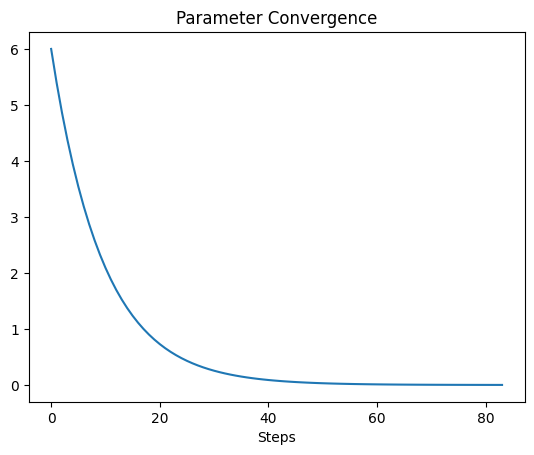

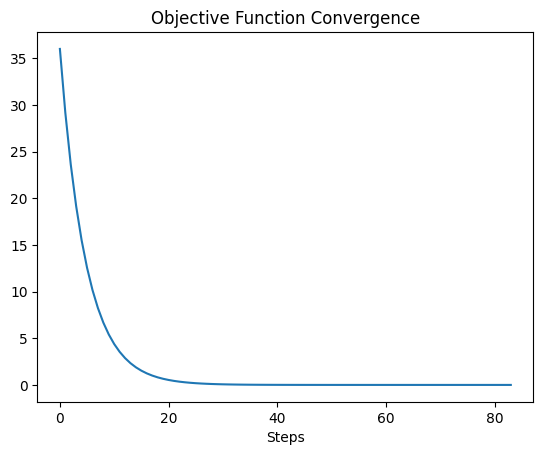

In [4]:
# 1. Gradient of a single parameter function (Numerical Diff)

# let's say we have a function, f(x) = x**2
def f(x):
    return x**2

# to get the gradient of this function for a value of x,
# we must compute the derivative of this function with respect to x

# There are a few ways to do this:
# ... numerical diff (manual approx., scipy)
# ... symbolic diff (sympy)
# ... autodiff (autograd, jax)

# for our experiment we will start from the most basic (numerical diff or approximate diff)
# this method essentially takes advantage of the base formula for a derivative to approximate differentiation
# ... f'(x) = f(x + h) - f(x) / h, as h approaches 0 (lim h->0)

def approx_diff(f, x, h):
    f_xh = f(x + h)
    f_x = f(x)

    d_dx_f = (f_xh - f_x) / h

    return d_dx_f

# - uncomment to run -
print("- Approximations for f'(x) using different values of 'h'")
for h in [5, 1, 0.1, 0.01, 0.001, 1e-4, 1e-5, 1e-12]:
   print(h, "\t",approx_diff(f, 4, h))

# notice how when h == 1e-12 we actually get a worse estimate than when h == 1e-4 ...
# this is because of the systems floating point precision!
# so the goal for this method is to balance accuracy and the precision of h for a system

# now, why is this useful
# we can use this to calculate gradients for Gradient Descent

# 2. Gradient Descent of single parameter function

# essentailly, what this is asking is:
# ... find the value of x that minimizes the function f by moving x a tiny step in the direction of -f'(x)
# ... if f'(x) > 0, the function is INCREASING -> move left
# ... if f'(x) < 0, the function is DECREASING -> move right

def gradient_descent(f, x, h=1e-4, alpha=5e-2, steps=99, tolerance=1e-6, print_s=False):
    print(f"\n- Gradient descent over {steps} steps")
    print(f"Initial input x: {x}, h: {h}, step_size (alpha): {alpha}")
    x_hist = [x]
    f_hist = [f(x)]
    # perform step
    # for each step we calculate x_new using GD's update rule
    # update rule: x_new = x - step_size * f'(x)
    for i in range(steps):
        x = x - (alpha * approx_diff(f, x, h))
        x_hist.append(x)
        f_hist.append(f(x))
        if abs(f(x)) <= tolerance:
            break
        if print_s:
            print(f"step {i+1}\t\t{x}")
    return x_hist, f_hist

# - uncomment to run -
x = random.randint(1,10)
x_hist, f_hist = gradient_descent(f, x)

plt.title("Parameter Convergence")
plt.xlabel("Steps")
plt.plot(x_hist)
plt.show()

plt.title("Objective Function Convergence")
plt.xlabel("Steps")
plt.plot(f_hist)
plt.show()


See how LR effects output of Gradient Descent

- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 0.0001


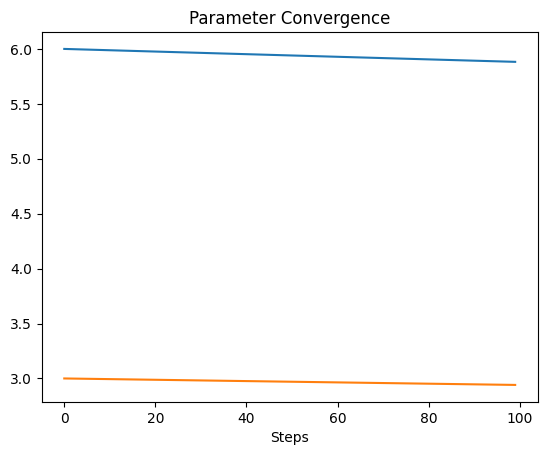

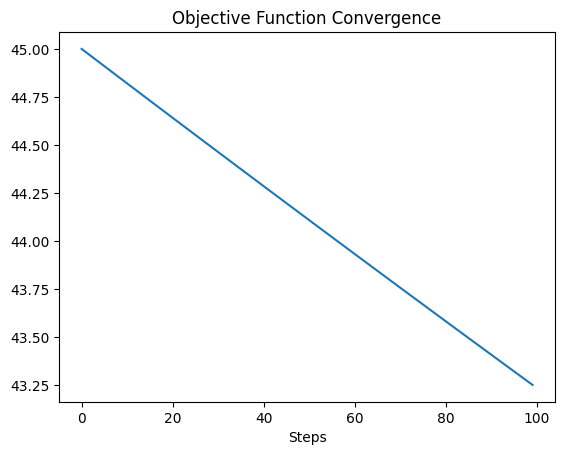


- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 0.01


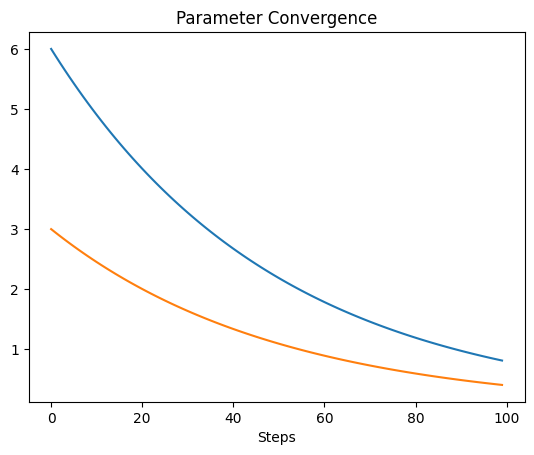

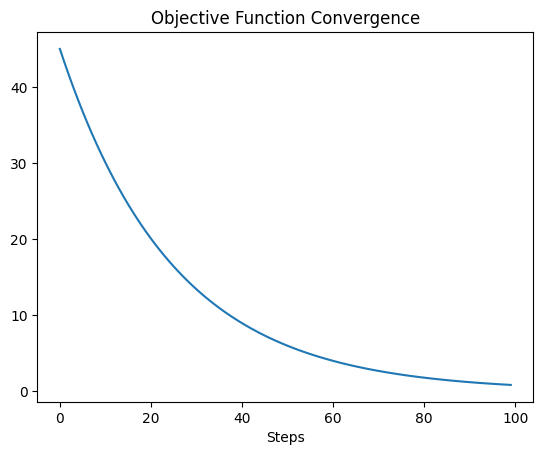


- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 0.05


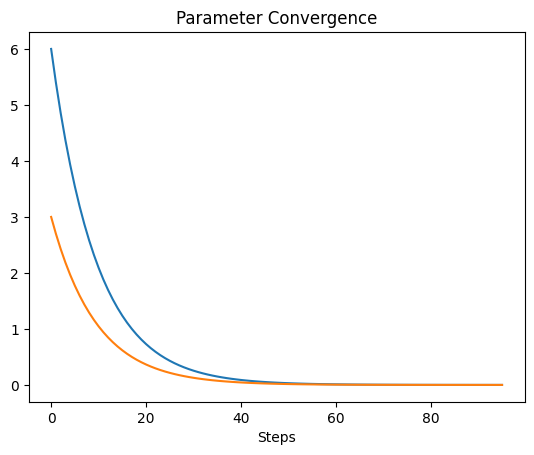

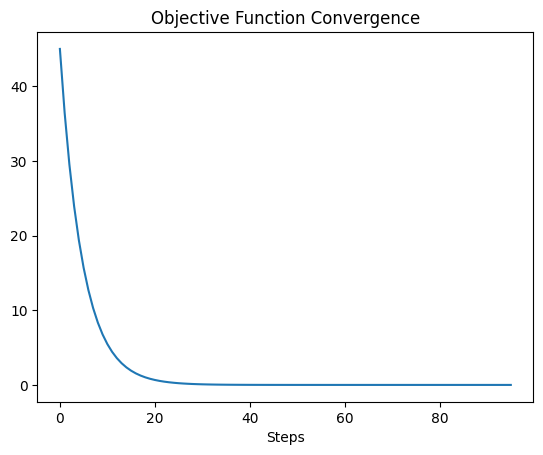


- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 0.2


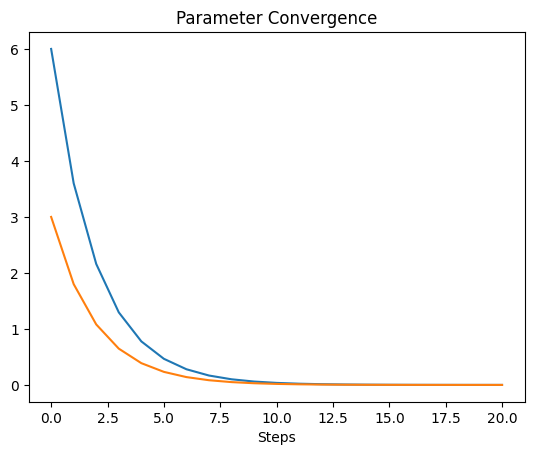

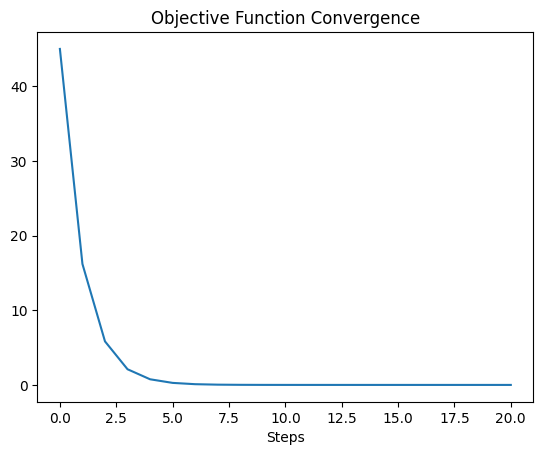


- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 0.8


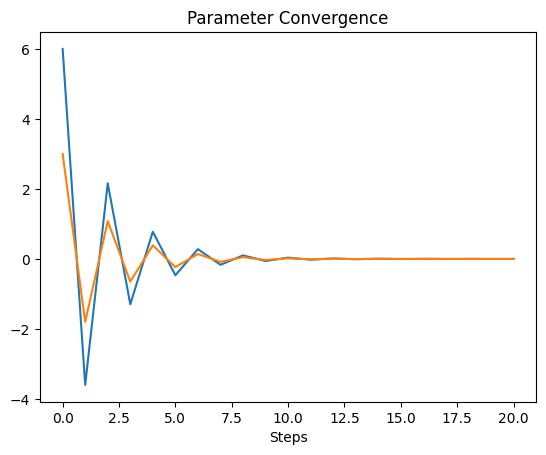

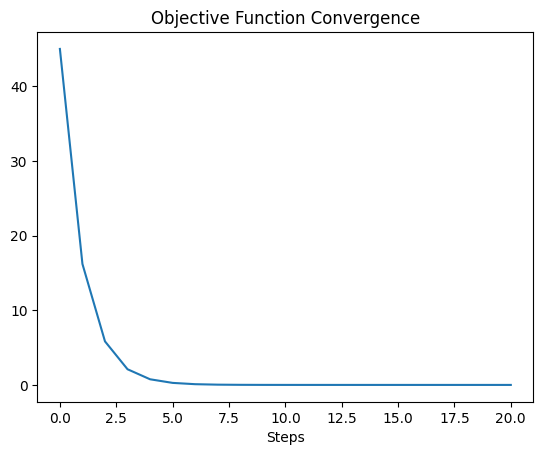


- Gradient descent over 99 steps
Initial input x: 6, y: 3, h: 1e-05, step_size (alpha): 1.1


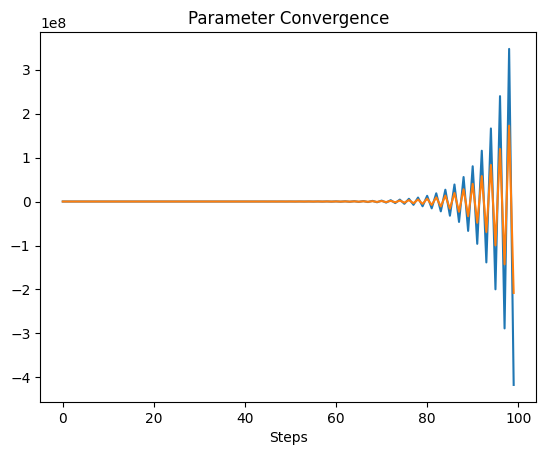

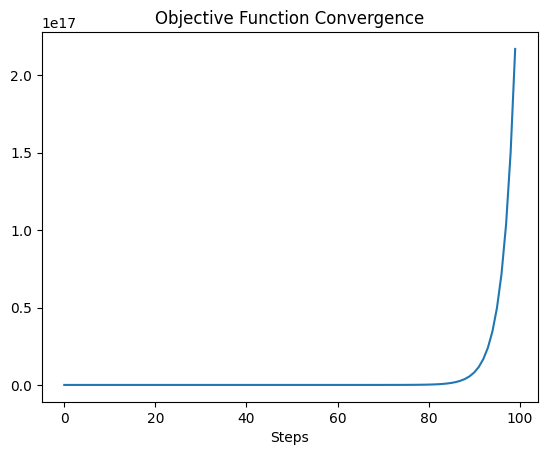

In [6]:
# 2. Gradient Descent of dual-parameter function (Numerical Diff)

# we can apply the same technique for multiple parameters,
# now taking the partial derivatives of each parameter

# lets say we have a function, f(x, y) = x**2 + y**2
def f(x, y):
    return x**2 + y**2

# again, we approximate the derivatives of each parameter using the base formula
# but this time, we will return a gradient containing the derivatives for each parameter
def partial_diff(f, x, y, h=1e-5):
    p_x = (f(x + h, y) - f(x, y)) / h
    p_y = (f(x, y + h) - f(x, y)) / h
    return np.array([p_x, p_y])

# we need to also tweak our gradient_descent algorithm to accommodate for this

# following the same update rule, we would now use vectors during the update step:
# ... [x_new, y_new] = [x, y] - step_size * [partial_x, partial_y]

def gradient_descent(f, x, y, h=1e-5, alpha=1e-2, steps=99, tolerance=1e-7):
    print(f"\n- Gradient descent over {steps} steps")
    print(f"Initial input x: {x}, y: {y}, h: {h}, step_size (alpha): {alpha}")
    params = np.array([x, y])
    param_hist = [params]
    f_hist = [f(x, y)]
    for i in range(steps):
        params = params - (alpha * partial_diff(f, params[0], params[1], h))
        param_hist.append(params)
        f_hist.append(f(params[0], params[1]))
        if abs(f(params[0], params[1])) <= tolerance:
            break
    return param_hist, f_hist

# - uncomment to run -
print("See how LR effects output of Gradient Descent")
x, y = 6, 3 # random.randint(1,5), random.randint(1,5)
for a in [1e-4, 1e-2, 5e-2, 0.2, 0.8, 1.1]:
    param_hist, f_hist = gradient_descent(f, x, y, alpha=a)
    
    plt.title("Parameter Convergence")
    plt.xlabel("Steps")
    plt.plot(param_hist)
    plt.show()
    
    plt.title("Objective Function Convergence")
    plt.xlabel("Steps")
    plt.plot(f_hist)
    plt.show()


In [15]:
# 3. Numerical Diff for multi-parameter functions

# here we will define some function, f, where f takes a vector of parameter values, X

def f(X):
    return sum(x**2 for x in X) / len(X)

# We now need to find how each parameter effects the output of f - how does f change when we change
# each parameter in X,
# to differentiate f with respect to each parameter in X, 
# we will need to take the partial derivative for each x_i in X -> giving us the gradient of f(X)

def numerical_diff(f, params, h=1e-5):
    partials = []
    f_base = f(params)
    for i, x in enumerate(params):
        # f'(X) = f(xi + h, X) - f(X) / h
        t_params = params.copy()
        t_params[i] = x + h
        partials.append((f(t_params) - f_base) / h)
        
    return np.array(partials)

ex_params = [2, 4, 8, 16, 32]
grad_f = numerical_diff(mse, ex_params)
print(grad_f)


[ 0.800002  1.600002  3.200002  6.400002 12.800002]



- Batch GD over 99 steps
Initial input X: [ 2.06502121 -0.15678153], w: [0.13963854 0.0578854 ], alpha: 0.02
Final weights: [0.13963854 0.0578854 ]


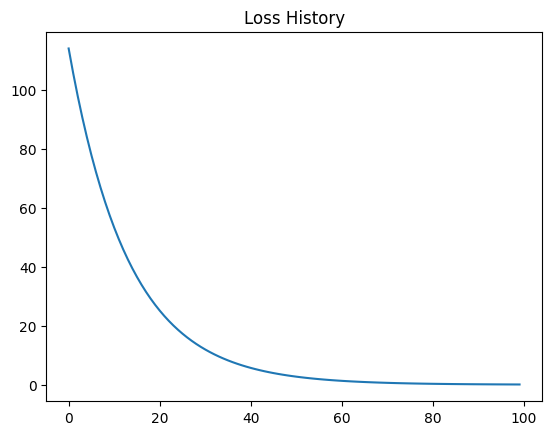

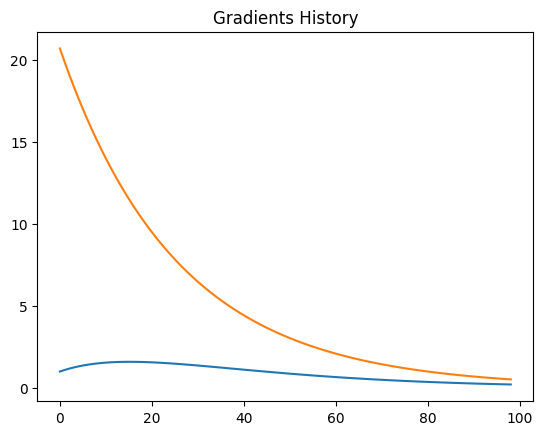

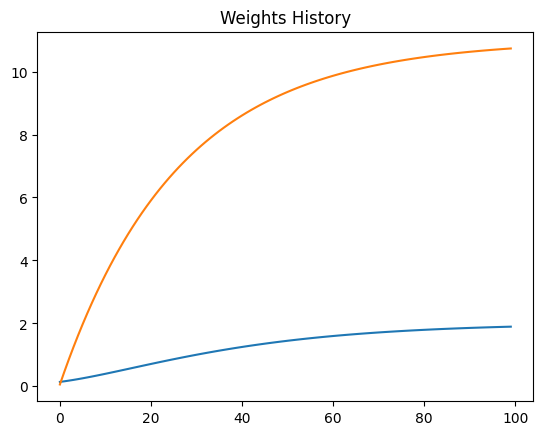

In [3]:
# 4. Gradient Descent on multiple samples / multi-parameters (Numerical Diff)
# a. Linear Regression Example
# ... In this cell we will use notation and naming conventions related to Machine Learning

# to further expand on the above cell (multi-parameter numerical diff - returning a gradient),
# we are going to see how we apply this to a small linear regression example using MSE loss

# we can accomplish this goal in many different ways, but for our example we will focus on Batch Gradient Descent,
# ... Batch GD computes the exact gradient at each step, making it
# ... easier to reason about convergence before introducing the noise of SGD
# ... where, SGD computes and applies a gradient per sample (1 sample per step)
# ... we will use a small amount of input data so Batch GD works well, but for larger input data, 
# ... it can be inefficient, which is where Mini-Batch GD comes into play (n samples per step)

# besides mse, we will perform calculations using matrices instead of vectors where,
# ... Rows -> Samples
# ... Columns -> Parameters -> Features
# we will denote matrices as capital letters, X, and vectors as lowercase, x

# - linear regression explaination
# we are trying to learn a function f that maps inputs X to predicted outputs ŷ, 
# by finding a weight vector W that minimizes the difference between our predictions and the true labels y.
# In notation: find W such that f(X, W) = XW ≈ y

# - optimization in linear regression
# we have a loss function L(W) defined over a parameter space. We use Gradient Descent to minimize
# L(W) with respect to W. Since L(W) depends on f(X, W) = XW, each update step moves W in the
# direction that most reduces prediction error — iteratively bringing ŷ = XW closer to y.
# Linear regression + MSE gives us a clean, convex loss surface to demonstrate this on

# - notation and data shapes
# ... X -> input data of shape (n_samples x n_features)
# ... w -> features vector of shape (n_features x 1)
# ... y -> true values vector of shape (n_samples x 1)
# ... y_hat -> predicted values vector of shape (n_samples x 1)


# MSE -> vector of mse's for each y_i, y_hat_i
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)
 
# Model Function
def f(X, w):
    return X @ w # -> y_hat

# Loss Function - Objective Function to minimize
def L(y, X, w):
    y_hat = f(X, w)
    return mse(y, y_hat)

# Gradient of Loss Function
def L_grad(y, X, w, h=1e-5):
    base_loss = L(y, X, w)
    grad = []
    for i in range(len(w)):
        # l'(y, X, w) = l(y, X, W_h) - l(y, X, w) / h
        # where, W_h = w := w_i + h
        W_h = w.copy()
        W_h[i] += h
        diff = (L(y, X, W_h) - base_loss) / h
        grad.append(diff)

    return np.array(grad)

# Optimization - Batch GD
def batch_GD(y, X, w, alpha=2e-2, steps=99):
    print(f"\n- Batch GD over {steps} steps")
    print(f"Initial input X: {X[0]}, w: {w}, alpha: {alpha}")
    grad_hist = []
    W_hist = [w]
    loss_hist = [L(y, X, w)]
    for i in range(steps):
        # w := w - alpha (gradient of L)
        grad = L_grad(y, X, w)
        w = w - alpha * grad
        
        grad_hist.append(-grad)
        W_hist.append(w)
        loss_hist.append(L(y, X, w))
    return grad_hist, W_hist, loss_hist


# true weights we are trying to recover
w_true = np.array([2.0, 11.0]) # (n_features,)

# random input matrix
X = np.random.randn(20, 2) # (n_samples, n_features)

# true output - values we are using to predict w
y = X @ w_true + np.random.randn(20) * 0.05 # for realistic noise

# starting weights
w = np.random.uniform(0.0, 0.5, (2,))

g_hs, w_hs, l_hs = batch_GD(y, X, w)

print(f"Final weights: {w}")

plt.title("Loss History")
plt.plot(l_hs)
plt.show()

plt.title("Gradients History")
plt.plot(g_hs)
plt.show()

plt.title("Weights History")
plt.plot(w_hs)
plt.show()

